## "French Motor TPL Insurance" dataset

Classification + regression on the same dataset (hurdle model).

This dataset is about insurance claims ("ClaimAmount") on French motors.

* https://www.kaggle.com/code/karansarpal/insurance-data-science-project-ks
* https://github.com/GregDataMiner/Insurance-Data-Science-Project---French-Motor-TPL-Insurance-Claims-Data/tree/main

Example notebooks:

* https://github.com/lorentzenchr/Tutorial_freMTPL2/blob/master/glm_freMTPL2_example.ipynb

---

In [ ]:
import pandas as pd

df = pd.read_csv("hurdle_french_motor_insurance.csv")

df

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount
0,2219170,0,0.08,4,2,36,95,B1,Regular,E,9307,Rhone-Alpes,0.0
1,3173597,0,0.80,9,12,56,50,B3,Regular,B,65,Pays-de-la-Loire,0.0
2,3010438,0,0.65,5,1,70,68,B12,Regular,E,4128,Pays-de-la-Loire,0.0
3,2180736,0,1.00,5,13,81,50,B1,Regular,C,247,Bretagne,0.0
4,1134937,0,1.00,5,8,67,50,B1,Regular,B,61,Centre,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,4137499,0,1.00,8,7,57,50,B2,Diesel,C,209,Basse-Normandie,0.0
99996,1102649,0,0.23,7,0,33,50,B2,Regular,D,1957,Ile-de-France,0.0
99997,4179131,0,0.12,6,13,50,50,B2,Regular,A,44,Centre,0.0
99998,4071463,0,0.37,8,2,30,54,B12,Regular,D,645,Corse,0.0


In [ ]:
# Get column info

def get_column_info(df):
    """
    Returns a summary DataFrame with dtypes, null counts, 
    unique values for objects, and min/max for numeric columns.
    """
    summary_list = []
    
    for col in df.columns:

        # Basic info
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        non_null_count = df[col].notnull().sum()
        
        unique_values = df[col].unique().tolist()
        min_val = None
        max_val = None
        
        # Info for numeric columns (Int/Float)
        if pd.api.types.is_numeric_dtype(dtype):
            min_val = df[col].min()
            max_val = df[col].max()
        else: # Sort categorical unique values
            unique_values = sorted(unique_values)
            
        summary_list.append({
            'Column': col,
            'Type': dtype,
            'Nulls': null_count,
            'Non-Nulls': non_null_count,
            'Unique Count': df[col].nunique(),
            'Unique Values': unique_values,
            'Min': min_val,
            'Max': max_val
        })
    
    return pd.DataFrame(summary_list).sort_values(by='Type')

get_column_info(df)

,Column,Type,Nulls,Non-Nulls,Unique Count,Unique Values,Min,Max
0,IDpol,int64,0,100000,100000,"[2219170, 3173597, 3010438, 2180736, 1134937, ...",11.000000,6114328.00
1,ClaimNb,int64,0,100000,6,"[0, 1, 2, 3, 9, 4]",0.000000,9.00
3,VehPower,int64,0,100000,12,"[4, 9, 5, 7, 6, 13, 8, 11, 12, 10, 14, 15]",4.000000,15.00
4,VehAge,int64,0,100000,55,"[2, 12, 1, 13, 8, 20, 0, 3, 14, 10, 5, 4, 11, ...",0.000000,100.00
5,DrivAge,int64,0,100000,81,"[36, 56, 70, 81, 67, 39, 57, 60, 27, 66, 32, 2...",18.000000,99.00
6,BonusMalus,int64,0,100000,93,"[95, 50, 68, 64, 90, 76, 80, 63, 54, 87, 51, 1...",50.000000,218.00
10,Density,int64,0,100000,1568,"[9307, 65, 4128, 247, 61, 747, 3258, 298, 77, ...",1.000000,27000.00
2,Exposure,float64,0,100000,146,"[0.08, 0.8, 0.65, 1.0, 0.05, 0.06, 0.2, 0.07, ...",0.002732,1.98
12,ClaimAmount,float64,0,100000,1907,"[0.0, 1128.12, 790.88, 2045.75, 1204.0, 1128.0...",0.000000,382955.14
7,VehBrand,object,0,100000,11,"[B1, B10, B11, B12, B13, B14, B2, B3, B4, B5, B6]",NaN,NaN


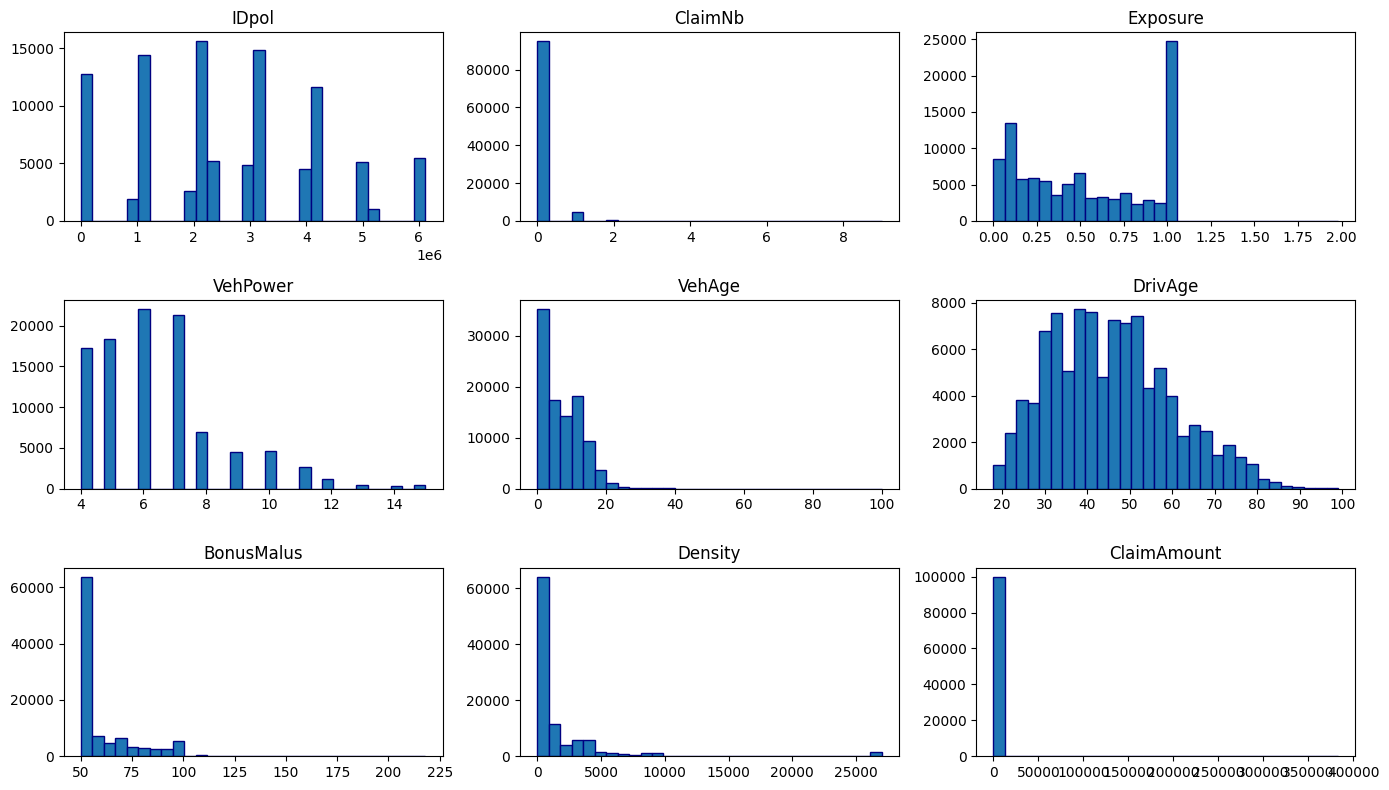

In [60]:
# Show histograms

import matplotlib.pyplot as plt

def plot_histograms(df):
    '''Print histogram for all columns'''
    df.hist(figsize=(14, 8), bins=30, edgecolor='navy', grid=False)
    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [ ]:
target_column = "ClaimAmount"
other_columns_to_drop = ["IDpol", "ClaimNb"]

y = df[target_column]
X = df.drop(columns=[target_column, *other_columns_to_drop])

display(X, y)

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,0.08,4,2,36,95,B1,Regular,E,9307,Rhone-Alpes
1,0.80,9,12,56,50,B3,Regular,B,65,Pays-de-la-Loire
2,0.65,5,1,70,68,B12,Regular,E,4128,Pays-de-la-Loire
3,1.00,5,13,81,50,B1,Regular,C,247,Bretagne
4,1.00,5,8,67,50,B1,Regular,B,61,Centre
...,...,...,...,...,...,...,...,...,...,...
99995,1.00,8,7,57,50,B2,Diesel,C,209,Basse-Normandie
99996,0.23,7,0,33,50,B2,Regular,D,1957,Ile-de-France
99997,0.12,6,13,50,50,B2,Regular,A,44,Centre
99998,0.37,8,2,30,54,B12,Regular,D,645,Corse


0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
99995    0.0
99996    0.0
99997    0.0
99998    0.0
99999    0.0
Name: ClaimAmount, Length: 100000, dtype: float64

In [130]:
# Check categorical columns

def get_all_categories(df):
    """Get names and unique values for every column with type 'object'"""

    obj_cols = df.select_dtypes(include=['object']).columns
    data = []

    for col in obj_cols:
        data.append({
            'column_name': col,
            'unique_values': df[col].unique().tolist(),
            'value_count': len(df[col].unique()),
        })
    
    return pd.DataFrame(data)

get_all_categories(X)

,column_name,unique_values,value_count
0,VehBrand,"[B1, B3, B12, B11, B4, B13, B2, B5, B10, B6, B14]",11
1,VehGas,"[Regular, Diesel]",2
2,Area,"[E, B, C, D, A, F]",6
3,Region,"[Rhone-Alpes, Pays-de-la-Loire, Bretagne, Cent...",21


In [131]:
# Option 1: encode manually with map + convert to categories

# Map categories to integers manually
area_mapping = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5}
gas_mapping = {"Regular": 0, "Diesel": 1}

# For high-cardinality nominal columns, we can automate the mapping dictionary
region_mapping = {val: i for i, val in enumerate(df["Region"].unique())}
brand_mapping = {val: i for i, val in enumerate(df["VehBrand"].unique())}

# --- STEP 2: Apply .map() AND set to 'category' ---
# We map the strings to integers, then immediately cast to the 'category' dtype

X_encoded = X.copy()
X_encoded["Area"] = X_encoded["Area"].map(area_mapping).astype("category")
X_encoded["VehGas"] = X_encoded["VehGas"].map(gas_mapping).astype("category")
X_encoded["Region"] = X_encoded["Region"].map(region_mapping).astype("category")
X_encoded["VehBrand"] = X_encoded["VehBrand"].map(brand_mapping).astype("category")

X_encoded

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,0.08,4,2,36,95,0,0,4,9307,0
1,0.80,9,12,56,50,1,0,1,65,1
2,0.65,5,1,70,68,2,0,4,4128,1
3,1.00,5,13,81,50,0,0,2,247,2
4,1.00,5,8,67,50,0,0,1,61,3
...,...,...,...,...,...,...,...,...,...,...
99995,1.00,8,7,57,50,6,1,2,209,10
99996,0.23,7,0,33,50,6,0,3,1957,4
99997,0.12,6,13,50,50,6,0,0,44,3
99998,0.37,8,2,30,54,2,0,3,645,9


In [126]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       100000 non-null  int64   
 1   ClaimNb     100000 non-null  int64   
 2   Exposure    100000 non-null  float64 
 3   VehPower    100000 non-null  int64   
 4   VehAge      100000 non-null  int64   
 5   DrivAge     100000 non-null  int64   
 6   BonusMalus  100000 non-null  int64   
 7   VehBrand    100000 non-null  category
 8   VehGas      100000 non-null  category
 9   Area        100000 non-null  category
 10  Density     100000 non-null  int64   
 11  Region      100000 non-null  category
dtypes: category(4), float64(1), int64(7)
memory usage: 6.5 MB


In [132]:
# Option 2: Encode with ordinal encoder + convert to categories

from sklearn.preprocessing import OrdinalEncoder

def encode_categorical_columns(df: pd.DataFrame, categorical_columns: list[str]) -> pd.DataFrame:
    '''Convert categorical columns into Int64 categories'''
    encoder = OrdinalEncoder(dtype=int, handle_unknown='use_encoded_value', unknown_value=-1).set_output(transform="pandas")

    encoded_cols = encoder.fit_transform(X[categorical_columns]).astype('category')

    df_encoded = df.copy()
    df_encoded[categorical_columns] = encoded_cols
    return df_encoded

cat_cols = ['VehBrand', 'VehGas', 'Area', 'Region']
X_encoded_2 = encode_categorical_columns(X, cat_cols)

display(X_encoded_2.info(), X_encoded_2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   Exposure    100000 non-null  float64 
 1   VehPower    100000 non-null  int64   
 2   VehAge      100000 non-null  int64   
 3   DrivAge     100000 non-null  int64   
 4   BonusMalus  100000 non-null  int64   
 5   VehBrand    100000 non-null  category
 6   VehGas      100000 non-null  category
 7   Area        100000 non-null  category
 8   Density     100000 non-null  int64   
 9   Region      100000 non-null  category
dtypes: category(4), float64(1), int64(5)
memory usage: 5.0 MB


None

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,0.08,4,2,36,95,0,1,4,9307,20
1,0.80,9,12,56,50,7,1,1,65,16
2,0.65,5,1,70,68,3,1,4,4128,16
3,1.00,5,13,81,50,0,1,2,247,5
4,1.00,5,8,67,50,0,1,1,61,6
...,...,...,...,...,...,...,...,...,...,...
99995,1.00,8,7,57,50,6,0,2,209,3
99996,0.23,7,0,33,50,6,1,3,1957,11
99997,0.12,6,13,50,50,6,1,0,44,6
99998,0.37,8,2,30,54,3,1,3,645,8


In [170]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2)


# Scale X data

cols_to_scale = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    # "VehBrand",
    # "VehGas",
    # "Area",
    "Density",
    # "Region",
]

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler().set_output(transform="pandas")
# X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
# X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

display(X_train, X_test)

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
42705,1.00,5,6,48,50,1,1,0,21,3
80866,0.30,5,0,71,50,2,1,1,86,2
46495,0.83,4,1,71,50,0,1,2,182,3
46238,0.06,9,4,50,50,0,1,0,13,3
74818,0.58,7,5,50,50,4,1,0,12,3
...,...,...,...,...,...,...,...,...,...,...
37782,1.00,4,7,57,50,6,0,1,91,3
44940,0.21,6,3,31,76,9,0,2,155,3
46986,0.97,4,12,52,118,9,0,2,200,0
9230,0.23,7,4,36,55,1,1,0,18,3


,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
5342,0.120000,6,10,51,50,0,1,1,60,10
92214,1.000000,7,4,42,52,6,1,5,14200,4
45234,1.000000,9,12,50,50,0,0,2,135,0
10903,1.000000,9,8,79,50,0,1,1,65,2
66924,0.240000,7,3,25,106,2,1,3,670,0
...,...,...,...,...,...,...,...,...,...,...
64091,0.640000,6,5,27,85,0,1,2,238,5
92318,0.005464,5,4,29,76,6,1,3,551,11
74983,1.000000,8,15,54,50,0,1,4,3317,7
97332,1.000000,7,6,67,50,6,1,0,46,3


In [153]:
# Utility functions

def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).style.format({ "Value": "{:,.2f}" }) # Round to 2 decimals


from sklearn.metrics import classification_report
def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose().round(2)


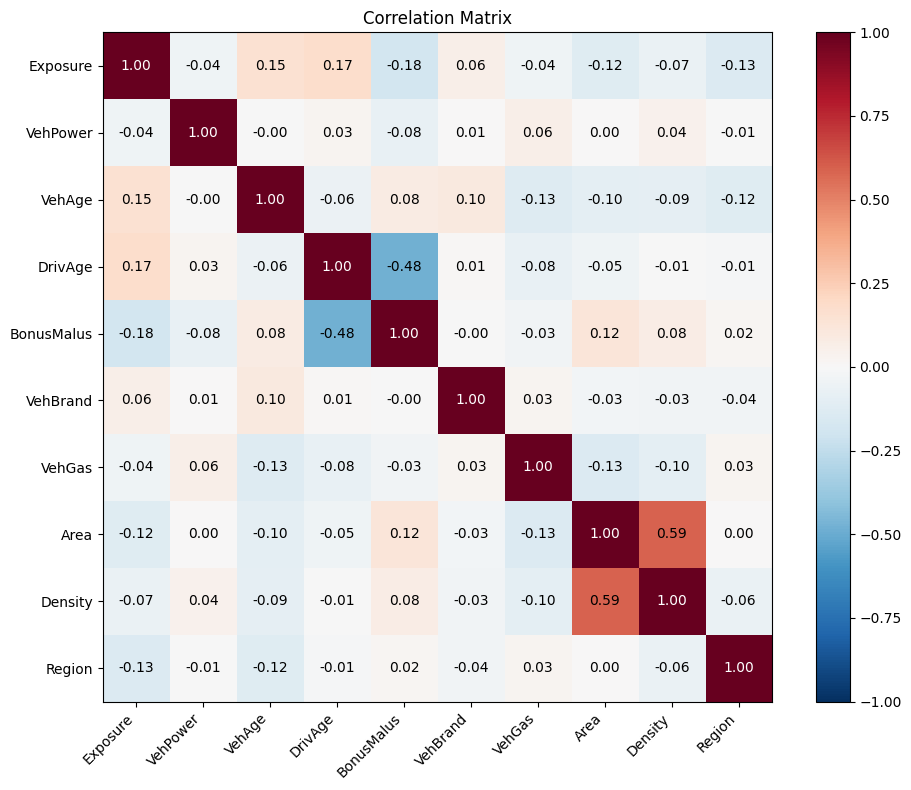

In [171]:
show_correlation_matrix(X_train)

In [ ]:
# Part 1: train regressor on the entire dataset

In [ ]:
# TODO - grid search on regressor

In [172]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingRegressor(categorical_features="from_dtype", max_iter=100)

# Fit the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Check accuracy
get_regression_metrics(y_test, y_pred)

,Metric,Value
0,MAE,144.22
1,MSE,"845,152.56"
2,RMSE,919.32
3,R2 Score,-0.05


In [173]:
# We can check the predicions manually if we want

pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred,
    "error": round(y_pred - y_test, 1),
})

,y_test,y_pred,error
5342,0.0,47.289623,47.3
92214,0.0,87.639747,87.6
45234,0.0,69.295774,69.3
10903,0.0,74.366671,74.4
66924,0.0,82.632497,82.6
...,...,...,...
64091,0.0,82.783328,82.8
92318,0.0,45.755890,45.8
74983,0.0,75.980289,76.0
97332,0.0,69.295774,69.3


In [ ]:
# Part 2a: train classifier on entire dataset

In [174]:
# Convert target column from float to 0/1
y_train_class = (y_train>0).astype(int)
y_test_class = (y_test>0).astype(int)

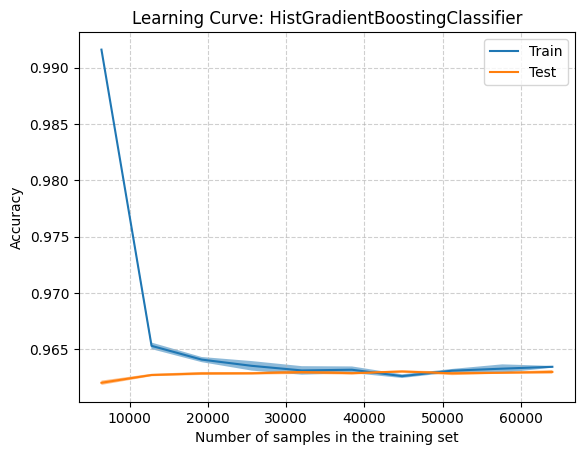

In [175]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier()
plot_learning_curve(model, X_train, y_train_class, classification=True)

In [176]:
# Grid search on classifier

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0],
    'early_stopping': [True],
    'class_weight': ['balanced', None],
}

grid_search = GridSearchCV(HistGradientBoostingClassifier(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train_class)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'class_weight': None, 'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}
Best score: 0.9631000000000001


In [177]:
best_params = {'class_weight': None, 'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingClassifier(**best_params, categorical_features="from_dtype")

# Fit the model
model.fit(X_train, y_train_class)
y_pred_class = model.predict(X_test)

# Check accuracy
get_classification_report(y_test_class, y_pred_class)

,precision,recall,f1-score,support
0,0.96,1.00,0.98,19291.00
1,0.50,0.00,0.00,709.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.73,0.50,0.49,20000.00
weighted avg,0.95,0.96,0.95,20000.00


In [178]:
# Check results
pd.DataFrame({
    "y_test": y_test_class,
    "y_pred (classifier)": y_pred_class,
    "correct?": y_pred_class == y_test_class,
})

,y_test,y_pred (classifier),correct?
5342,0,0,True
92214,0,0,True
45234,0,0,True
10903,0,0,True
66924,0,0,True
...,...,...,...
64091,0,0,True
92318,0,0,True
74983,0,0,True
97332,0,0,True


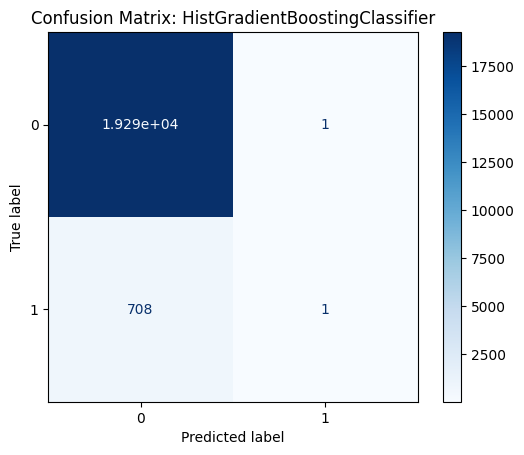

In [179]:
show_confusion_matrix(model, y_test_class, y_pred_class)

In [ ]:
# Part 2b: train regressor on but only on rows where y > 0

In [180]:
# Filter rows where y > 0
X_train_regr = X_train[y_train > 0]
y_train_regr = y_train[y_train > 0]

In [181]:
# Grid search on regressor

from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(HistGradientBoostingRegressor(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_regr, y_train_regr)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 200}
Best score: 0.003897718621852353


In [185]:
from sklearn.ensemble import HistGradientBoostingRegressor

best_params = {'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 200}

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingRegressor(**best_params, categorical_features="from_dtype")

# Fit the model
model.fit(X_train_regr, y_train_regr)
y_pred_regr = model.predict(X_test)

# Check accuracy (on the full unfiltered train data)
get_regression_metrics(y_test, y_pred_regr)

,Metric,Value
0,MAE,"2,665.52"
1,MSE,"8,788,754.74"
2,RMSE,"2,964.58"
3,R2 Score,-9.87


In [ ]:
# Part 3: combine the two predictions (classifier + regressor)

In [186]:
import numpy as np

y_pred_combined = np.where(y_pred_class == 0, 0, y_pred_regr)

# Check the results: classifier, regressor, combined
pd.DataFrame({
    "y_test": y_test,
    "y_pred (classifier)": y_pred_class,
    "y_pred (regressor)": y_pred_regr,
    "y_pred (combined)": y_pred_combined,
})

,y_test,y_pred (classifier),y_pred (regressor),y_pred (combined)
5342,0.0,0,3997.219922,0.0
92214,0.0,0,1339.442847,0.0
45234,0.0,0,1436.487604,0.0
10903,0.0,0,2124.601852,0.0
66924,0.0,0,2573.412150,0.0
...,...,...,...,...
64091,0.0,0,1809.321318,0.0
92318,0.0,0,3905.568066,0.0
74983,0.0,0,2090.777232,0.0
97332,0.0,0,1444.009619,0.0


In [188]:
get_regression_metrics(y_test, y_pred_combined)

,Metric,Value
0,MAE,65.37
1,MSE,"812,830.29"
2,RMSE,901.57
3,R2 Score,-0.01
